# 16 — Director outputs of the Y2Y-wide analysis within Alberta (14's cells on 15's package: the same files, sizes, style and export settings)

Runs on its own once `15_tiers_and_clusters_y2y_analysis` has written `director_package_y2y_analysis/` — tweak a figure here and re-run
the one cell; nothing upstream is recomputed. Compare each file with its namesake in `director_package/director_outputs/` (14, the Alberta run). Every output is ONE call to the shared `director_plot` asset
that 14 and the Y2Y-wide 21 call; the only differences are the package path, the Y2Y-wide manifest, and the objectives table's words.
Outputs → `director_package_y2y_analysis/director_outputs/`.

**Map conventions (Ethan 2026-09-30, M20.9):** the whole Y2Y-wide allocation is drawn beyond the Alberta PU, muted, with Alberta outlined as the
area of focus (`dp.load(context=…)`, `STYLE["context_alpha"]` / `focus_outline`); every protected-area cell grey with light borders between parks
(`pa_fill_all`, `pa_borders`); BC pinned on the frame (`main_codes`); insets widened to the whole strip (`inset_fit_pu`); the Alberta gazetteer
(`dc.ALBERTA_TOWNS`) on the insets. Every knob is in cell 1.


In [1]:
import importlib, json, pathlib, sys, textwrap
from types import SimpleNamespace
import numpy as np
import pandas as pd
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.py").exists()]
assert _cands, "config.py not found above the notebook"
ROOT = _cands[0]; sys.path.insert(0, str(ROOT))
import config, leverage_core as lc, ensemble_core as ec, director_core as dc, director_plot as dp
for _m in (config, lc, ec, dc, dp):
    importlib.reload(_m)
HERE = ROOT / "analyses" / "alberta_prioritization"; PKG = HERE / "director_package_y2y_analysis"; GEO, TAB = PKG / "geotiffs", PKG / "tables"
assert (PKG / "summary.json").exists(), "run 15_tiers_and_clusters_y2y_analysis first"
S = json.loads((PKG / "summary.json").read_text())
assert S.get("version", "v1") == config.Y2Y_VERSION, f"the package on disk is {S.get('version', 'v1')}, config is {config.Y2Y_VERSION} -- run 15 first"
assert S.get("runs_source", "").startswith("analyses/y2y/"), "this package must be the Y2Y-wide-within-Alberta build (15)"
# the Alberta grid as a director_core-compatible object (the parent grid masked to Alberta: same shape, same transform)
AB = config.ab_paths().stack                                   # the version's Alberta stack
with rasterio.open(AB / "cost_uniform.tif") as src:
    tr, shp, prof = src.transform, src.shape, src.profile
pu = lc.pu_mask(AB)
with rasterio.open(AB / "mask_protected_areas.tif") as src:
    locked2d = (src.read(1) == 1) & pu
G = SimpleNamespace(pu=pu, locked2d=locked2d, locked=locked2d[pu], disc=~locked2d[pu], n_pu=int(pu.sum()), n_disc=int((~locked2d[pu]).sum()),
                    shape=shp, transform=tr, crs=config.TARGET_CRS, profile=prof, cell_km2=abs(tr.a * tr.e) / 1e6)
G.rows, G.cols = np.where(pu)
rows_, cols_ = np.where(G.pu.any(axis=1))[0], np.where(G.pu.any(axis=0))[0]
R0, R1, C0, C1 = max(rows_.min() - 10, 0), min(rows_.max() + 11, G.shape[0]), max(cols_.min() - 10, 0), min(cols_.max() + 11, G.shape[1])
WIN = (float(C0), float(C1), float(R0), float(R1))                                       # the Alberta strip (x0, x1, y_top, y_bottom)
from rasterio import features as rfeatures
EXTENT_POLY = gpd.read_file(HERE / "data" / "ab_extent_v1.gpkg").to_crs(G.crs)                     # the Alberta extent polygon = the area-of-focus outline
FOCUS = rfeatures.rasterize(((g, 1) for g in EXTENT_POLY.geometry), out_shape=G.shape, transform=G.transform, fill=0, dtype="uint8").astype(bool)
AOI = gpd.read_file(GEO / "aoi.gpkg")                                                    # the Upper Smoky Nature-First zone + SRP planning area (12)
OVERLAY = SimpleNamespace(gdf=AOI.assign(ls=["-" if "Nature-First" in n else (0, (4, 2)) for n in AOI.name],
                                     legend=["Upper Smoky Nature-First zone" if "Nature-First" in n else "Upper Smoky sub-regional plan area" for n in AOI.name]),   # one legend entry per outline: solid / dashed (Ethan 2026-09-30)
                          mask2d=None,
                          label="Upper Smoky areas of interest (not locked in)")
# presentation knobs -- ONE place; edit and re-run (the Y2Y-wide values stay in director_plot.STYLE; these are the Alberta settings)
AB_TOWNS = ("Grande Prairie", "Grande Cache", "Hinton", "Jasper", "Banff", "Canmore")   # the frame's towns (drawn where the label fits inside the strip);
AB_GAZETTEER = {**dc.Y2Y_TOWNS, **dc.ALBERTA_TOWNS}                                                            # the insets draw EVERY gazetteer town inside their window (Ethan 2026-09-30)
BC_PIN = {"BC": (-118.18, 51.11)}                                                                              # the BC code on the frame (lon, lat): open BC land west of the strip, clear of the inset boxes and the scale bar
dp.STYLE.update(pa_layer_min_km2=50,            # named-PA floor for the insets / locators (read at load)
                window_scale_km=100,            # the scale bar on the Alberta frame
                inset_min_km=160, inset_pad_km=25,   # the zoom window around the key cluster (Y2Y-wide: 320 / 45)
                towns=AB_TOWNS, wide_main_towns=AB_TOWNS, wide_main_names="abbrev", lat53=False,
                inset_windows=None, scenario_inset_windows=None, scenario_inset_area_skip={}, scenario_inset_town_skip={}, inset_town_skip={"B": ("Rocky Mountain House",)},   # the Y2Y-wide FIXED windows (parent M4.39) are off here; per-inset town skips (Ethan 2026-09-30: no Rocky Mountain House on B)
                main_codes=dict(at=BC_PIN),     # "BC" on the frame, pinned on open BC land west of the strip (the automatic rule finds no open land there: BC's part of the frame is Y2Y region)
                inset_fit_pu=True,              # each inset window widened to the whole Alberta strip over its rows (+ pad) and centred on it, so the whole strip fits (Ethan 2026-09-30)
                pa_fill_all=True,               # every protected-area cell grey whether or not it is a planning unit: the icefields inside Jasper / Banff and the BC parks beyond the PU edge (Ethan 2026-09-30)
                pa_borders=("white", 0.3, 0.75),   # light lines along the protected-area edges over the grey fill, so adjoining parks read apart (Ethan 2026-09-30)
                context_label=None,             # no legend entry for the Y2Y-wide context surface (Ethan 2026-09-30)
                wide_legend_between=True, wide_legend_fit=True, wide_legend_floor="frame",   # Act 1 legends (three entries here): centred between inset B and the frame's bottom and SHRUNK to fit the gap (Ethan 2026-09-30)
                scenario_insets_as_act1=True,   # the Act 2 map keeps the Act 1 panels A / B (Ethan 2026-09-30)
                # legends: the Y2Y-wide 21's behaviour, unchanged (Ethan 2026-09-30, "design changes FROM y2y wide"): the Act 1 box at the shared default under inset B,
                # the Act 2 box centred between the insets and the page bottom and shrunk to fit (scenario_legend_between, shared default); cluster numbers = the rimmed discs
                focus_outline=None,             # NO outline of the Alberta extent / PU (Ethan 2026-09-30: "remove the tracing of the PU mask"); ("#333333", 0.6) = the extent polygon's boundary
                locator_towns=True, locator_pa_names=4, locator_codes={},   # the locator windows under the stars: gazetteer towns + four park names for reference (Ethan 2026-09-30); no forced codes
                locator_town_skip={2: ("Revelstoke", "Lake Louise", "Canmore", "Cochrane", "Sundre", "Rocky Mountain House", "Golden"),   # per-window skips, by cluster number (Ethan 2026-09-30)
                                   3: ("Kananaskis Village", "Cochrane"),
                                   4: ("Blairmore",)},
                locator_own_number_only=True,   # each locator numbers only its own cluster; the others keep their outlines (Ethan 2026-09-30)
                border_style=("#7A7A7A", 0.6, (4, 2)),   # the US border drawn like the provincial lines (dashed grey), not a heavy solid line (Ethan 2026-09-30)
                scalebar_box=False,             # no backing under the frame's scale bar (Ethan 2026-09-30)
                north_arrow_pt=11, window_north_arrow_left=True,   # the frame's north arrow as the Y2Y-wide frame draws it: left of the bar on its baseline, ~11 pt, N above the tip (Ethan 2026-09-30)
                inset_shift_km={"B": (0, 20)},  # nudge a wide-map inset (east km, north km) after the same-scale fit: B up 20 km so cluster 3 stays out of it (Ethan 2026-09-30)
                map_layout="wide")              # slide-shaped: the frame at left, the inset at right
C = dp.load(pkg=PKG, grid=G, manifest=dc.MANIFEST, overlay=OVERLAY, window=WIN, hex_grid=False, towns=AB_GAZETTEER,     # the Y2Y-wide manifest (the package's formulations)
            context=dc.PKG / "geotiffs", focus=FOCUS)   # the WHOLE Y2Y-wide allocation drawn beyond the Alberta PU (muted, STYLE["context_alpha"]) with Alberta outlined as the area of
                                            # focus (STYLE["focus_outline"]): the same analysis this package is cut from, so BC is not blank (Ethan 2026-09-30)
globals().update({k: v for k, v in vars(C).items() if not k.startswith("_")})
OUT = PKG / "director_outputs"; OUT.mkdir(exist_ok=True)
KEY = int(PICKS[PICKS.act == "Act 1"].sort_values("km2", ascending=False).iloc[0].number) if len(PICKS[PICKS.act == "Act 1"]) else None
N1 = sorted(int(n) for n in PICKS[PICKS.act == "Act 1"].number)
dp.STYLE["inset_clusters"] = tuple(N1[:2])                                  # two insets on core clusters 1 and 2 (north -> south), as the Y2Y-wide 21 (Ethan 2026-09-30: the same layout); override: (KEY,) for one inset
A2 = PICKS[PICKS.act == "Act 2"].sort_values("km2", ascending=False)
dp.STYLE["scenario_insets"] = tuple(int(n) for n in A2.head(2).number) if len(A2) else ()   # the Act 2 map's windows: the two largest scenario picks (Y2Y-wide: three fixed windows) -- override here
RUNS_Y2Y = dc.RUNS                                                        # the Y2Y-wide members (the flagship's default; a timelapse would read them)
plt.rcParams.update(dp.SPEC_RC)          # every figure takes the table spec's type (Cronos Pro, ink/cap/mut)
dp.STYLE["titles"] = False               # the slide carries the title (as the Y2Y-wide 21); 13 keeps titles
dp.STYLE["export_dpi"] = 300             # full-screen slides (as the Y2Y-wide 21)
print(f"package {S['version']} (Y2Y-wide within Alberta: {S['runs_source']}) | core basis {C.CORE_BASIS} | {len(S['forms'])} positions | band {S['band']} | key cluster {KEY} | Act 2 windows {dp.STYLE['scenario_insets']} | outputs -> {OUT.relative_to(ROOT)}")


package v4 (Y2Y-wide within Alberta: analyses/y2y/runs_v4) | core basis balanced | 14 positions | band g05 | key cluster 2 | Act 2 windows (7, 5) | outputs -> analyses/alberta_prioritization/director_package_y2y_analysis/director_outputs


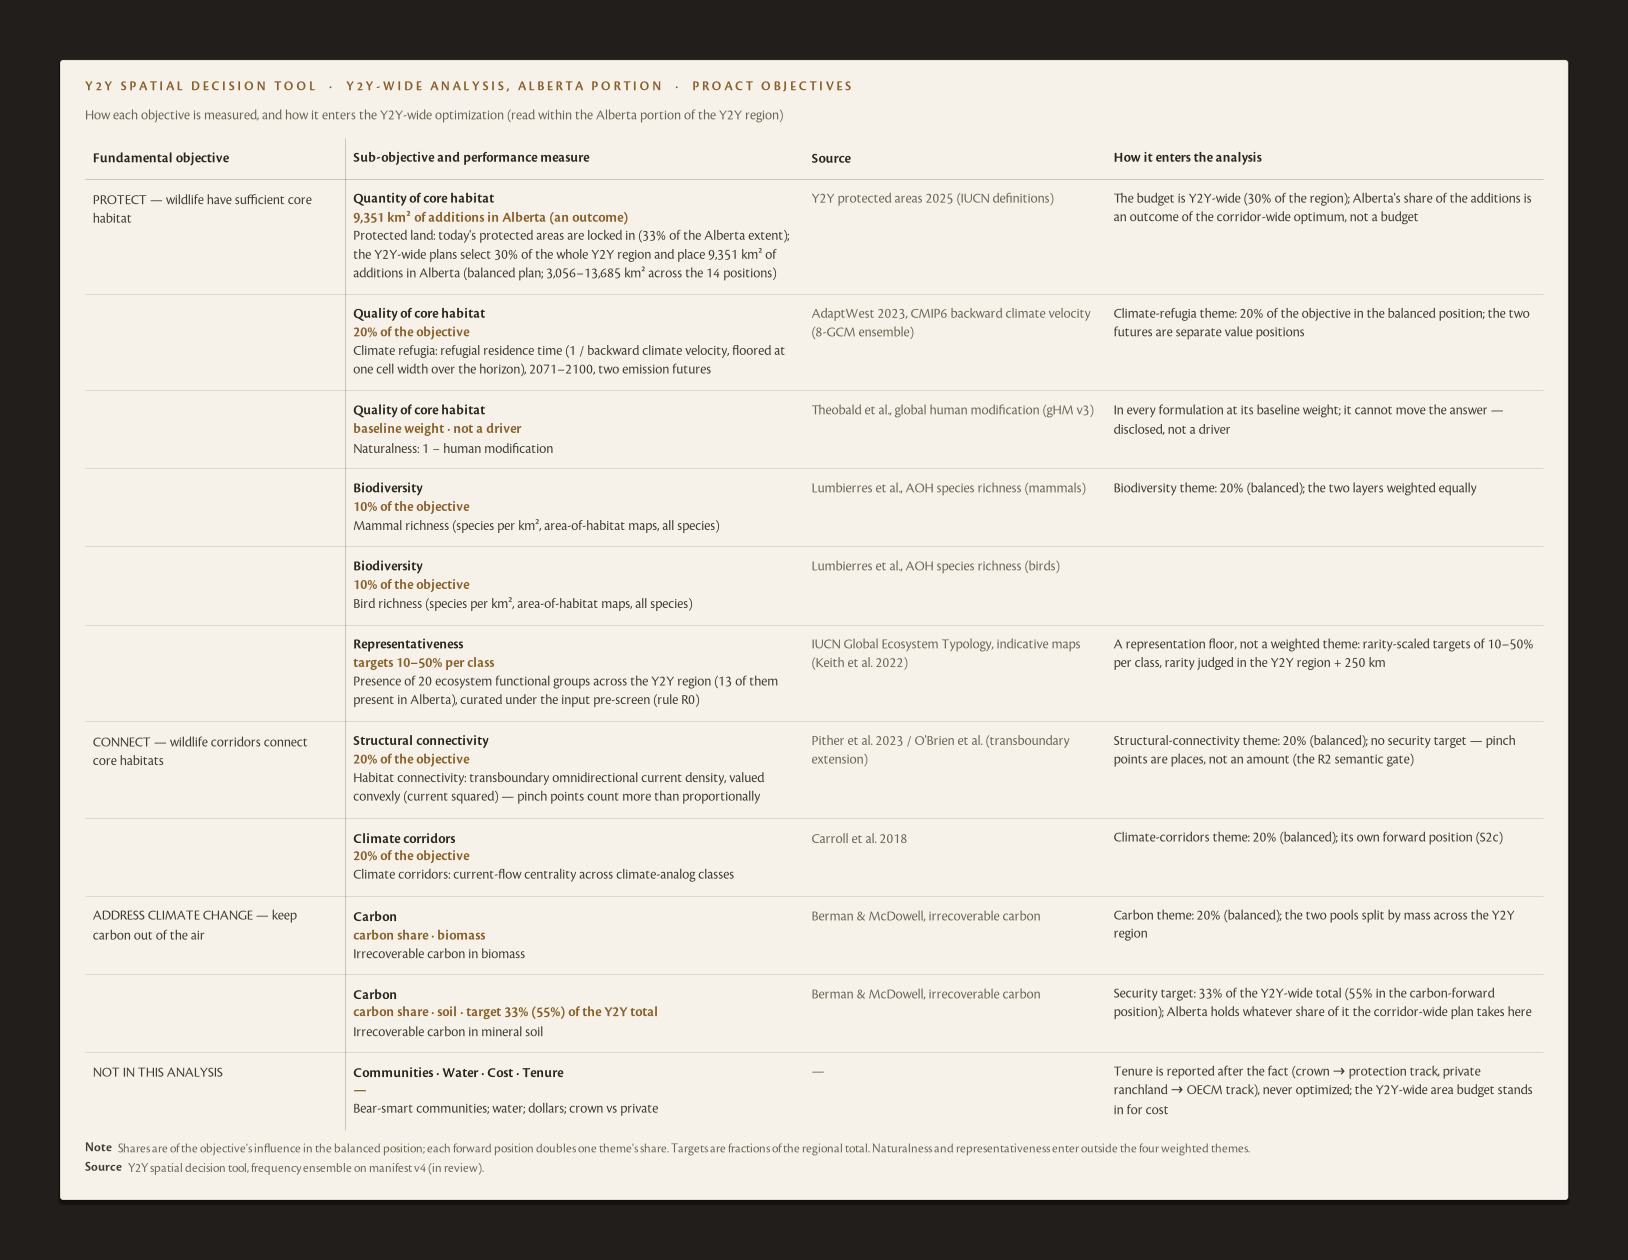

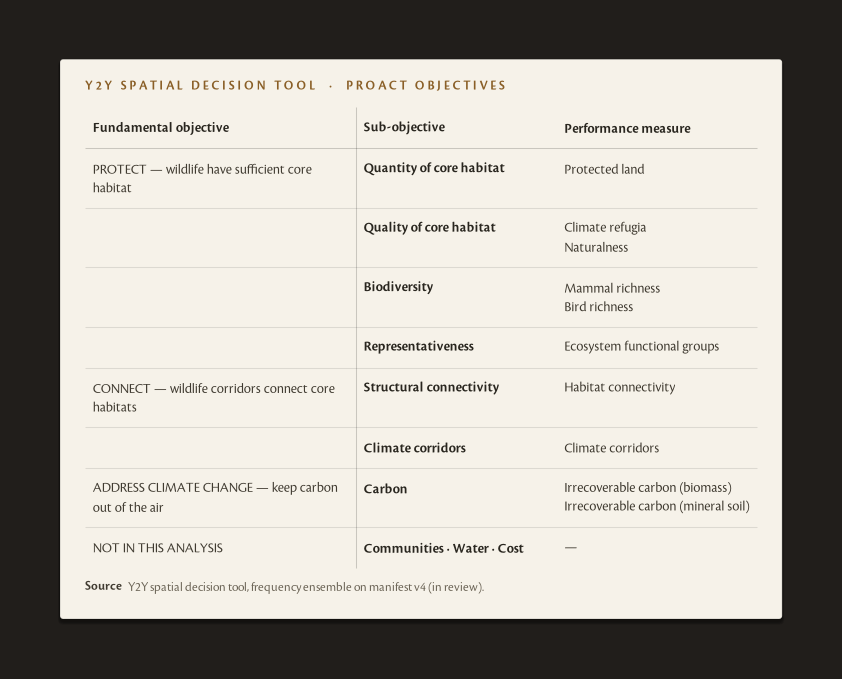

In [2]:
# ---- 1. the values in the analysis (the Y2Y-wide rows in Alberta terms from 15's record, rendered to the table spec) -------------------
ROWS0 = pd.read_csv(TAB / "T-D0_values_rows.csv").fillna("")
dp.values_table(C, OUT / "01_values_table.png", "Y2Y Objectives Hierarchy — the Y2Y-wide analysis in Alberta", rows=ROWS0[dp.VALUES_COLUMNS].values.tolist(), metrics=ROWS0.metric.tolist(),
                label="Y2Y SPATIAL DECISION TOOL  ·  Y2Y-WIDE ANALYSIS, ALBERTA PORTION  ·  PROACT OBJECTIVES",
                units="How each objective is measured, and how it enters the Y2Y-wide optimization (read within the Alberta portion of the Y2Y region)")
dp.values_table_simple(C, OUT / "01b_values_table_simple.png")     # the bare-bones version for the slides


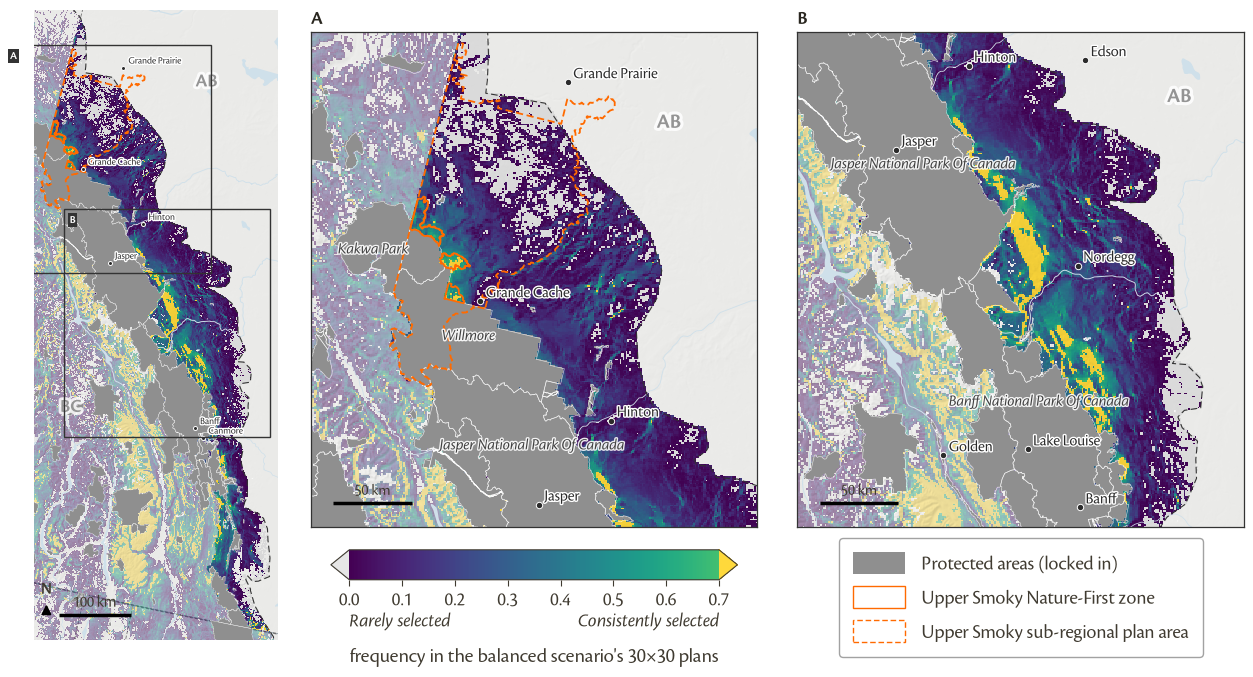

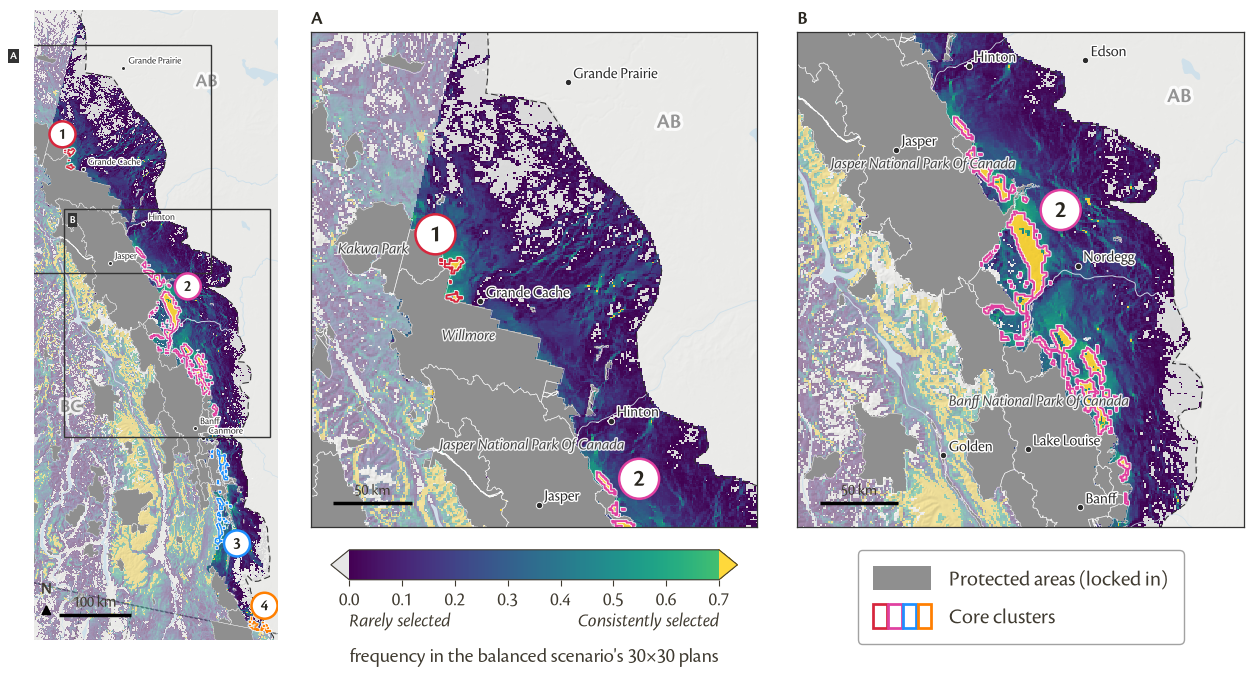

In [3]:
# ---- 2. Act 1 — THE CORE = the balanced scenario's guarded tier (package spec v2.1), two maps as the Y2Y-wide 21: (a) f over unprotected
#         land with the Upper Smoky areas of interest, (b) the regional core clusters (numbered north -> south); the Alberta frame + two insets ----
dp.core_map_F(C, OUT / "02a_act1_core_F.png")
dp.core_map_clusters(C, OUT / "02b_act1_core_clusters.png")
# the values-convergence pair stays one call away, as in 14:
# dp.values_map(C, OUT / "02c_act1_values_convergence.png"); dp.values_map(C, OUT / "02d_act1_values_convergence_clusters.png", with_clusters=True)


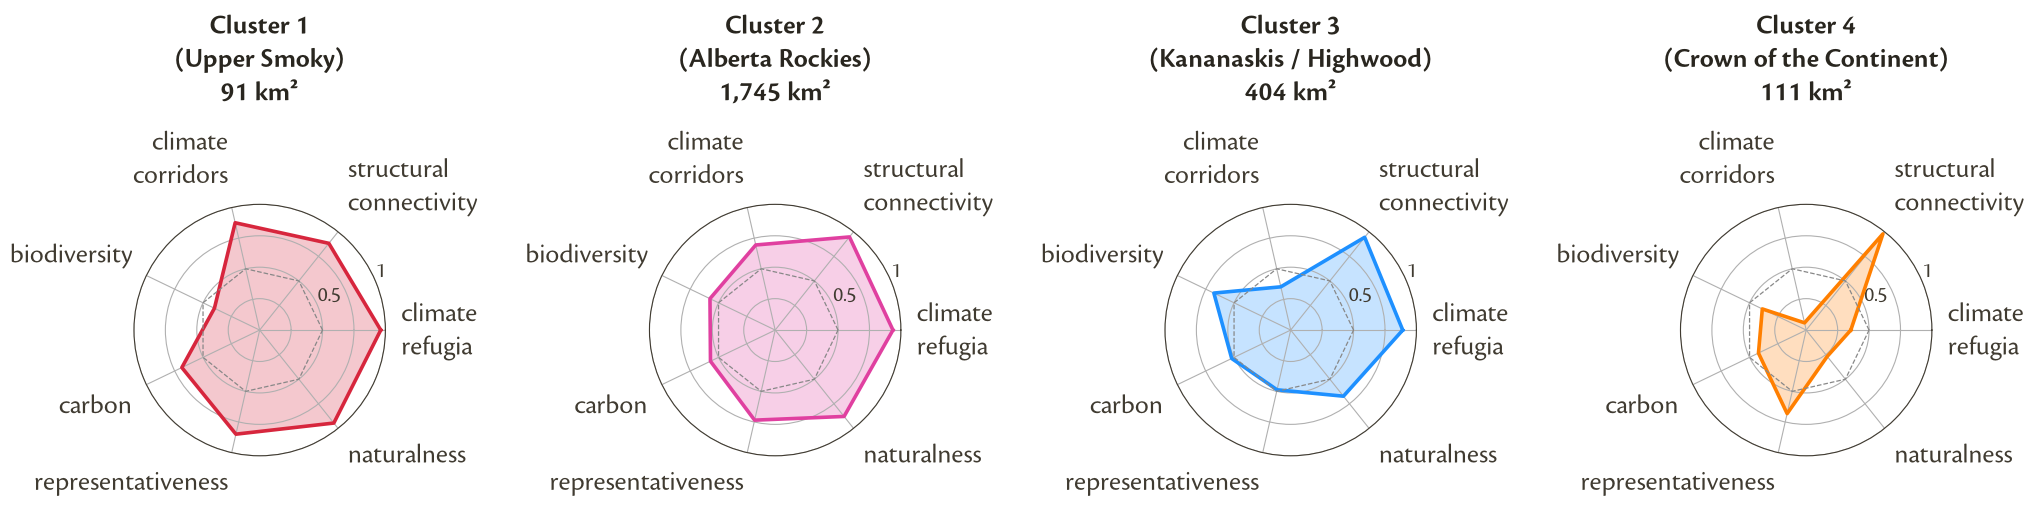

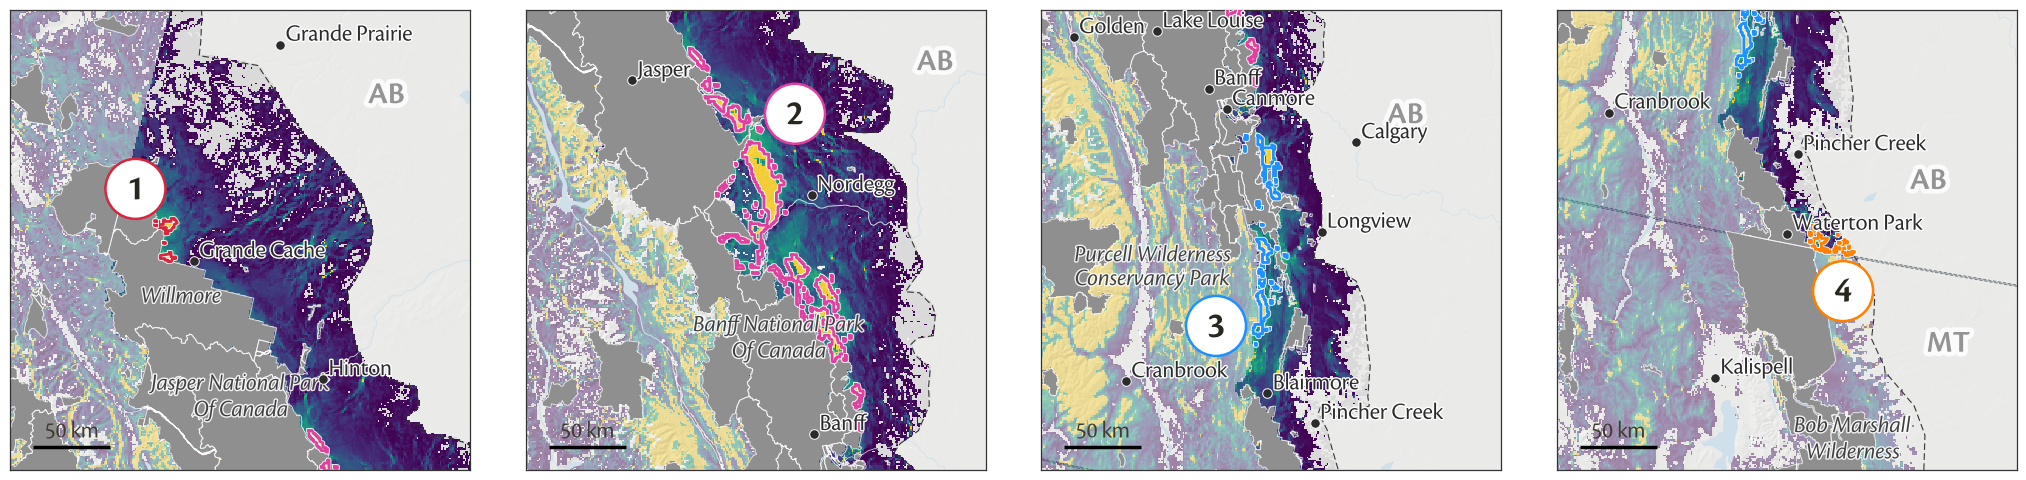

In [4]:
# ---- 3. Act 1 — star plots of the core clusters + one locator window per cluster (aligned under the stars; each also as its own file) ----
if len(C.numbered("Act 1")):
    dp.core_stars(C, OUT / "03_act1_core_stars.png")
    dp.cluster_locators(C, OUT / "03b_act1_cluster_locators.png", panel_px=620)
else:
    print("no core clusters -- no stars / locators")


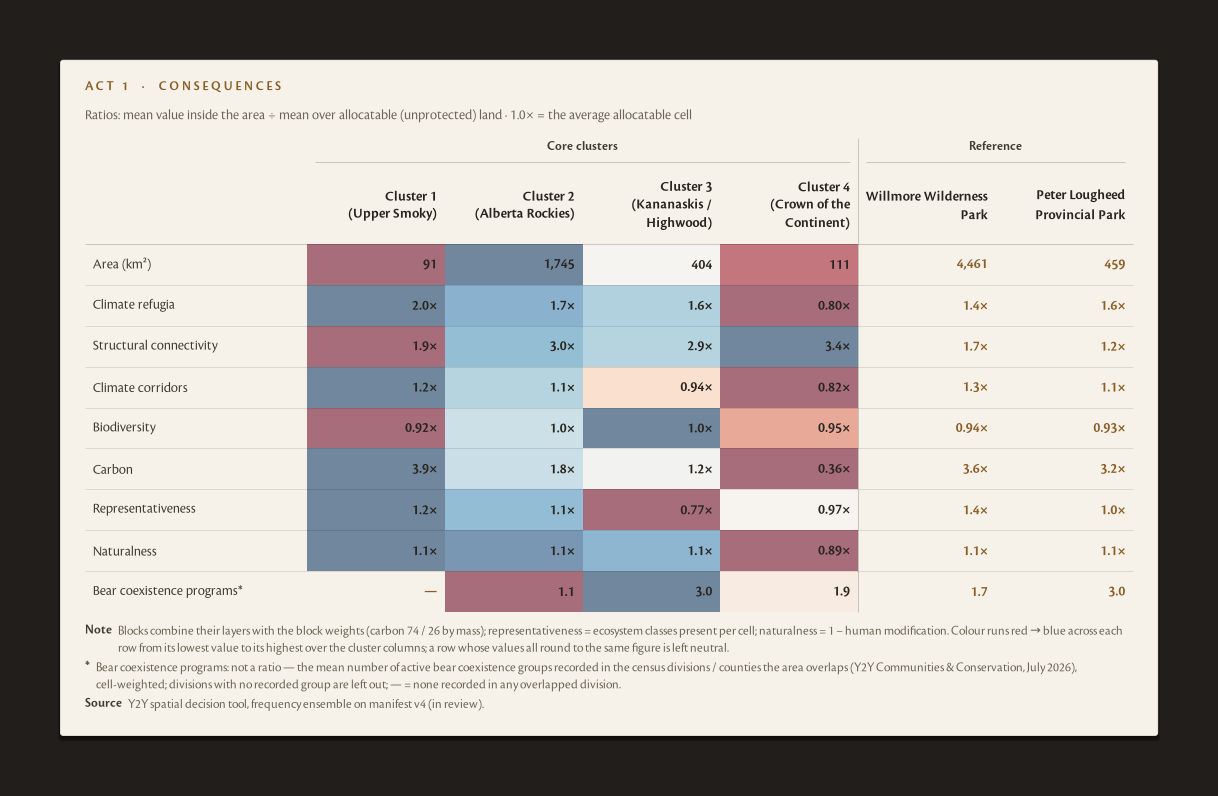

In [5]:
# ---- 4. Act 1 — consequences: mean value in the cluster / mean over Alberta's allocatable land ("2.3x"); reference columns = existing PAs,
#         the Upper Smoky Nature-First zone and planning area (unprotected parts) ----------------------------------------------------------
if len(C.numbered("Act 1")):
    dp.core_consequences(C, OUT / "04_act1_consequences.png")
else:
    print("no core clusters -- no consequences table")


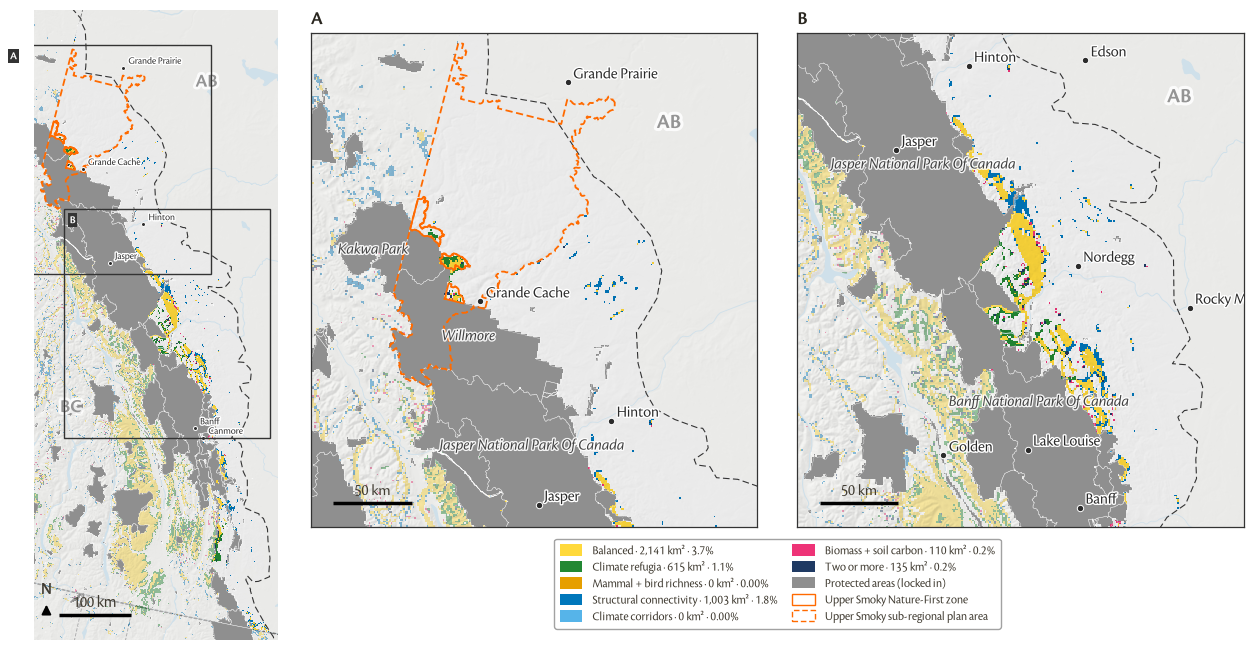

In [6]:
# ---- 5. Act 2 — ONE map: the tiers at 1 km, the scenario tier split by the position that earns it, windows on the two largest scenario picks,
#         area + share of allocatable land in the legend (the Y2Y-wide 21's 05) ----
if dp.STYLE["scenario_insets"]:
    dp.scenario_map(C, OUT / "05_act2_scenario_map.png")
else:
    print("no Act 2 picks -- no scenario map")


In [7]:
# ---- 6. the method timelapse: not an output here either (as 14); the call stays one line away ----
# FR = dp.method_frames(C, OUT / "06_method_frames", runs=RUNS_Y2Y)
